In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the data folder
# IMPORTANT: Replace 'YOUR_FILENAME.csv' with the exact name of the file you downloaded!
df = pd.read_csv('../data/Student_performance_data _.csv')

# Display the first 5 rows of the dataset
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


In [4]:
# 1. Check the size of the dataset (Rows, Columns)
print("Dataset Shape (Rows, Columns):", df.shape)
print("-" * 30)

# 2. Check for any missing or "null" values in the columns
print("Missing Values in Each Column:")
print(df.isnull().sum())
print("-" * 30)

# 3. Generate a mathematical summary of the numerical data (Average, Min, Max, etc.)
df.describe()

Dataset Shape (Rows, Columns): (2392, 15)
------------------------------
Missing Values in Each Column:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64
------------------------------


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


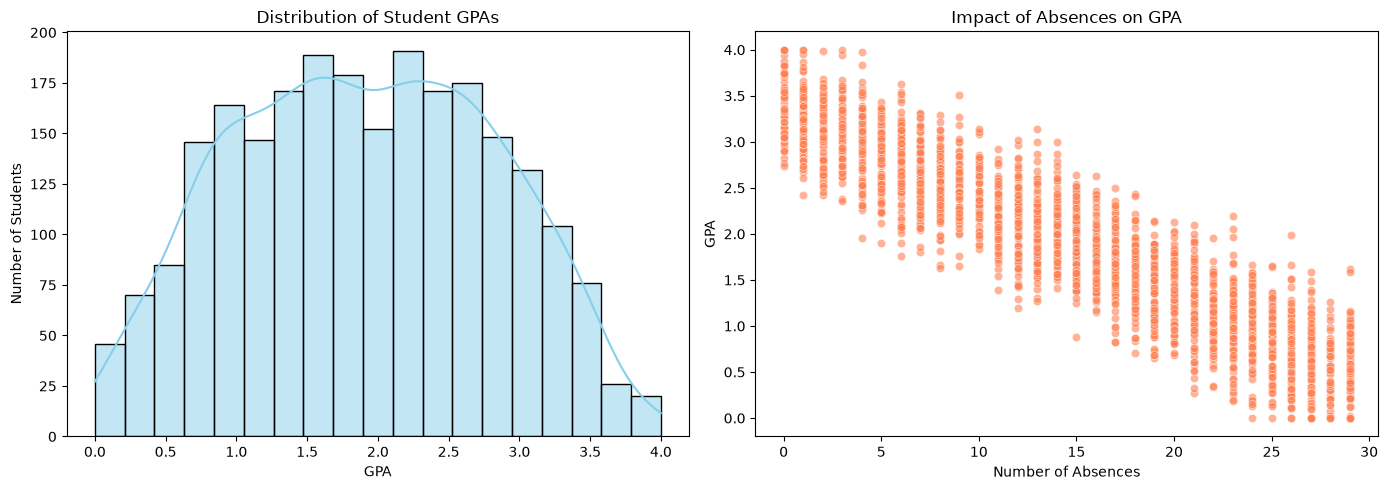

In [5]:
# Set up a plotting area with 2 charts side-by-side
plt.figure(figsize=(14, 5))

# Chart 1: Distribution of student GPAs
plt.subplot(1, 2, 1)
sns.histplot(df['GPA'], kde=True, color='skyblue')
plt.title('Distribution of Student GPAs')
plt.xlabel('GPA')
plt.ylabel('Number of Students')

# Chart 2: How Absences impact GPA
plt.subplot(1, 2, 2)
sns.scatterplot(x='Absences', y='GPA', data=df, alpha=0.6, color='coral')
plt.title('Impact of Absences on GPA')
plt.xlabel('Number of Absences')
plt.ylabel('GPA')

# Show the plots clearly
plt.tight_layout()
plt.show()

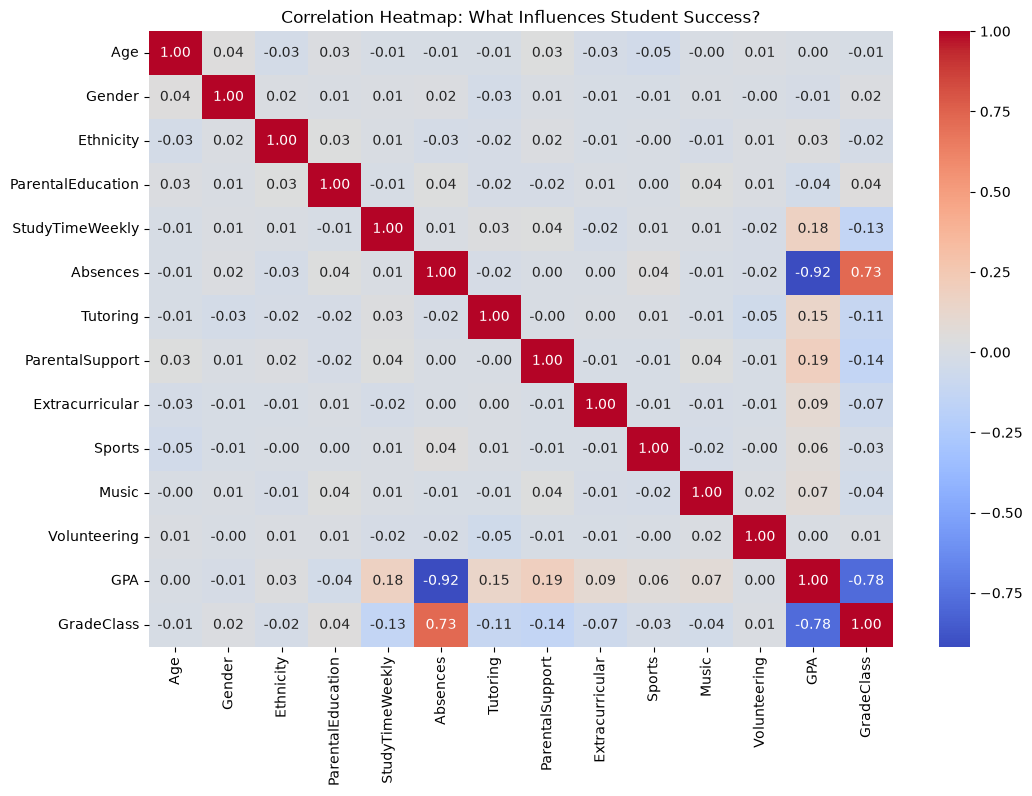

In [6]:
# Calculate how much each column relates to the others
# We drop 'StudentID' because a random ID number has no mathematical meaning for GPA
corr_matrix = df.drop(columns=['StudentID']).corr()

# Set up the plotting window
plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap: What Influences Student Success?')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Step 1: Separate inputs (X) from the target outcome (y)
X = df.drop(columns=['StudentID', 'GPA', 'GradeClass'])
y = df['GPA']

# Step 2: Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Verify the splits
print(f"Training features size: {X_train.shape}")
print(f"Testing features size: {X_test.shape}")
print("Data successfully split and ready for training!")

Training features size: (1913, 12)
Testing features size: (479, 12)
Data successfully split and ready for training!


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Initialize the Linear Regression Model
model = LinearRegression()

# Step 2: Train the model (This is where the magic/learning happens!)
model.fit(X_train, y_train)

# Step 3: Test the model by making predictions on the hidden test data
y_pred = model.predict(X_test)

# Step 4: Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🎉 Model Training Complete!")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (Accuracy): {r2 * 100:.2f}%")

🎉 Model Training Complete!
------------------------------
Mean Squared Error (MSE): 0.0387
R-squared Score (Accuracy): 95.32%


In [10]:
# Create a fictional student to test our AI
# You can change these numbers to try different scenarios!
custom_student = {
    'Age': 17,
    'Gender': 1,             # 1 = Male, 0 = Female
    'Ethnicity': 0,          # 0 = Caucasian, 1 = African American, 2 = Asian, 3 = Other
    'ParentalEducation': 2,  # 0 = None, 1 = High School, 2 = Some College, 3 = Bachelor's, 4 = Higher
    'StudyTimeWeekly': 15.0, # Hours spent studying per week
    'Absences': 2,           # Number of classes missed
    'Tutoring': 1,           # 1 = Yes, 0 = No
    'ParentalSupport': 3,    # 0 = None, 1 = Low, 2 = Medium, 3 = High, 4 = Very High
    'Extracurricular': 1,    # 1 = Yes, 0 = No
    'Sports': 0,             # 1 = Yes, 0 = No
    'Music': 1,              # 1 = Yes, 0 = No
    'Volunteering': 0        # 1 = Yes, 0 = No
}

# Convert the student data into a format the AI understands
custom_df = pd.DataFrame([custom_student])

# Tell the AI to predict the GPA
predicted_gpa = model.predict(custom_df)[0]

print("🤖 AI Prediction Result:")
print("-" * 30)
print(f"Predicted Student GPA: {predicted_gpa:.2f} out of 4.0")

🤖 AI Prediction Result:
------------------------------
Predicted Student GPA: 3.80 out of 4.0


In [11]:
import pickle

# Save the trained model structure to your deployment folder
with open('../deployment/student_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("📦 AI Model successfully serialized and saved to the deployment folder!")

📦 AI Model successfully serialized and saved to the deployment folder!
